<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect, text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from google.colab import userdata

engine = create_engine(userdata.get("NEON_DATABASE_URL"))
extract_query ="""
SELECT "CustomerID",
    "TotalRevenue",
    "Tenure",
    "Recency",
    "ProductDiversity",
    "Frequency"
FROM v_customer_metrics
"""

df = pd.read_sql(text(extract_query), con = engine)
print("Preview of Customer Segmentation Features")
df.head()

Preview of Customer Segmentation Features


,CustomerID,TotalRevenue,Tenure,Recency,ProductDiversity,Frequency
0,12346.0,77183.60,0,325,1,1
1,12347.0,2790.86,238,129,82,5
2,12348.0,1487.24,110,248,22,3
3,12350.0,334.40,0,310,17,1
4,12352.0,1561.81,34,262,26,4


/tmp/ipykernel_20070/170162039.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


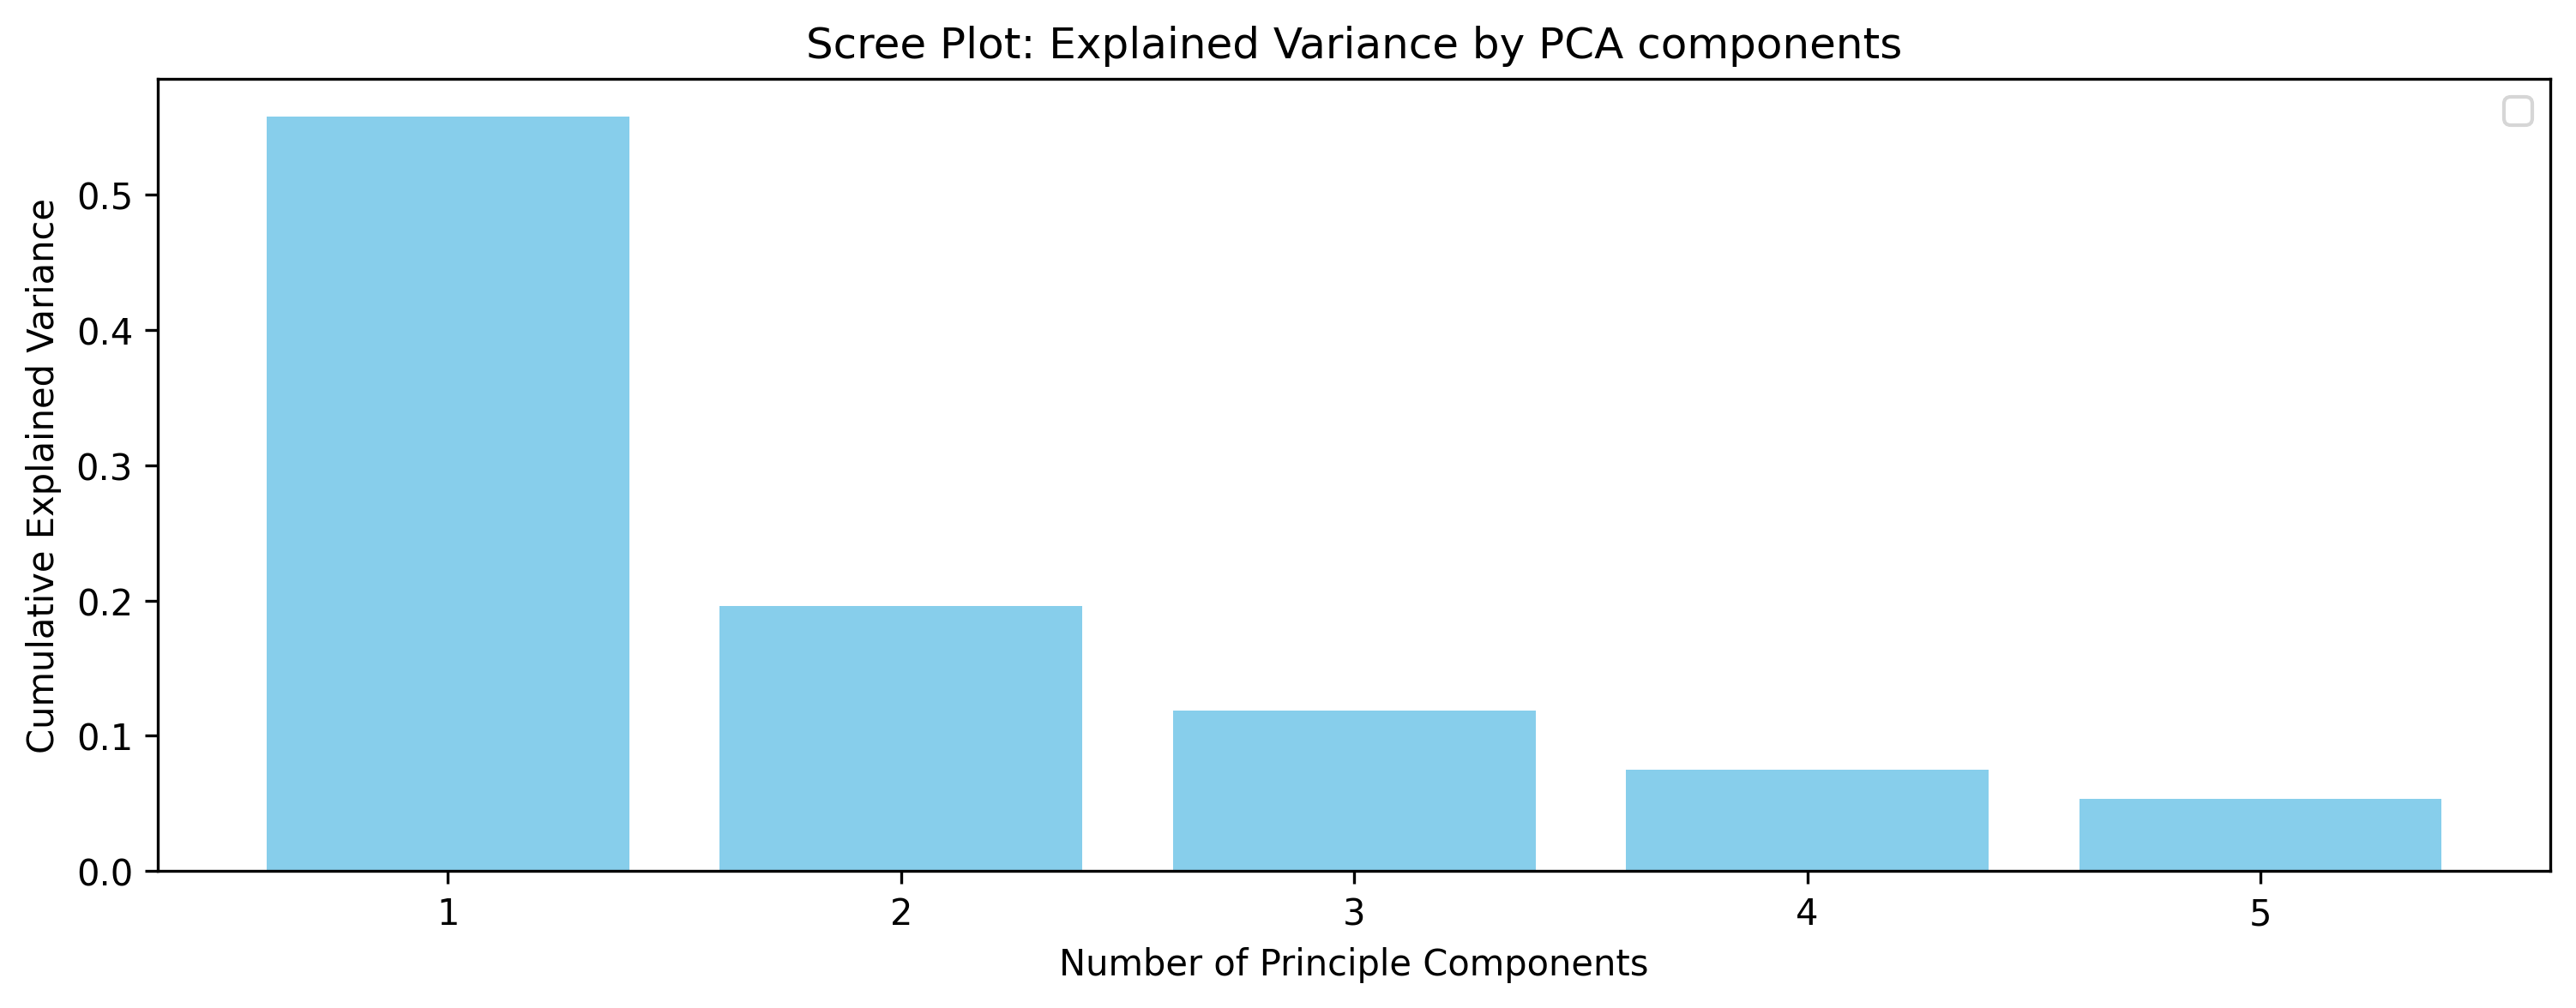

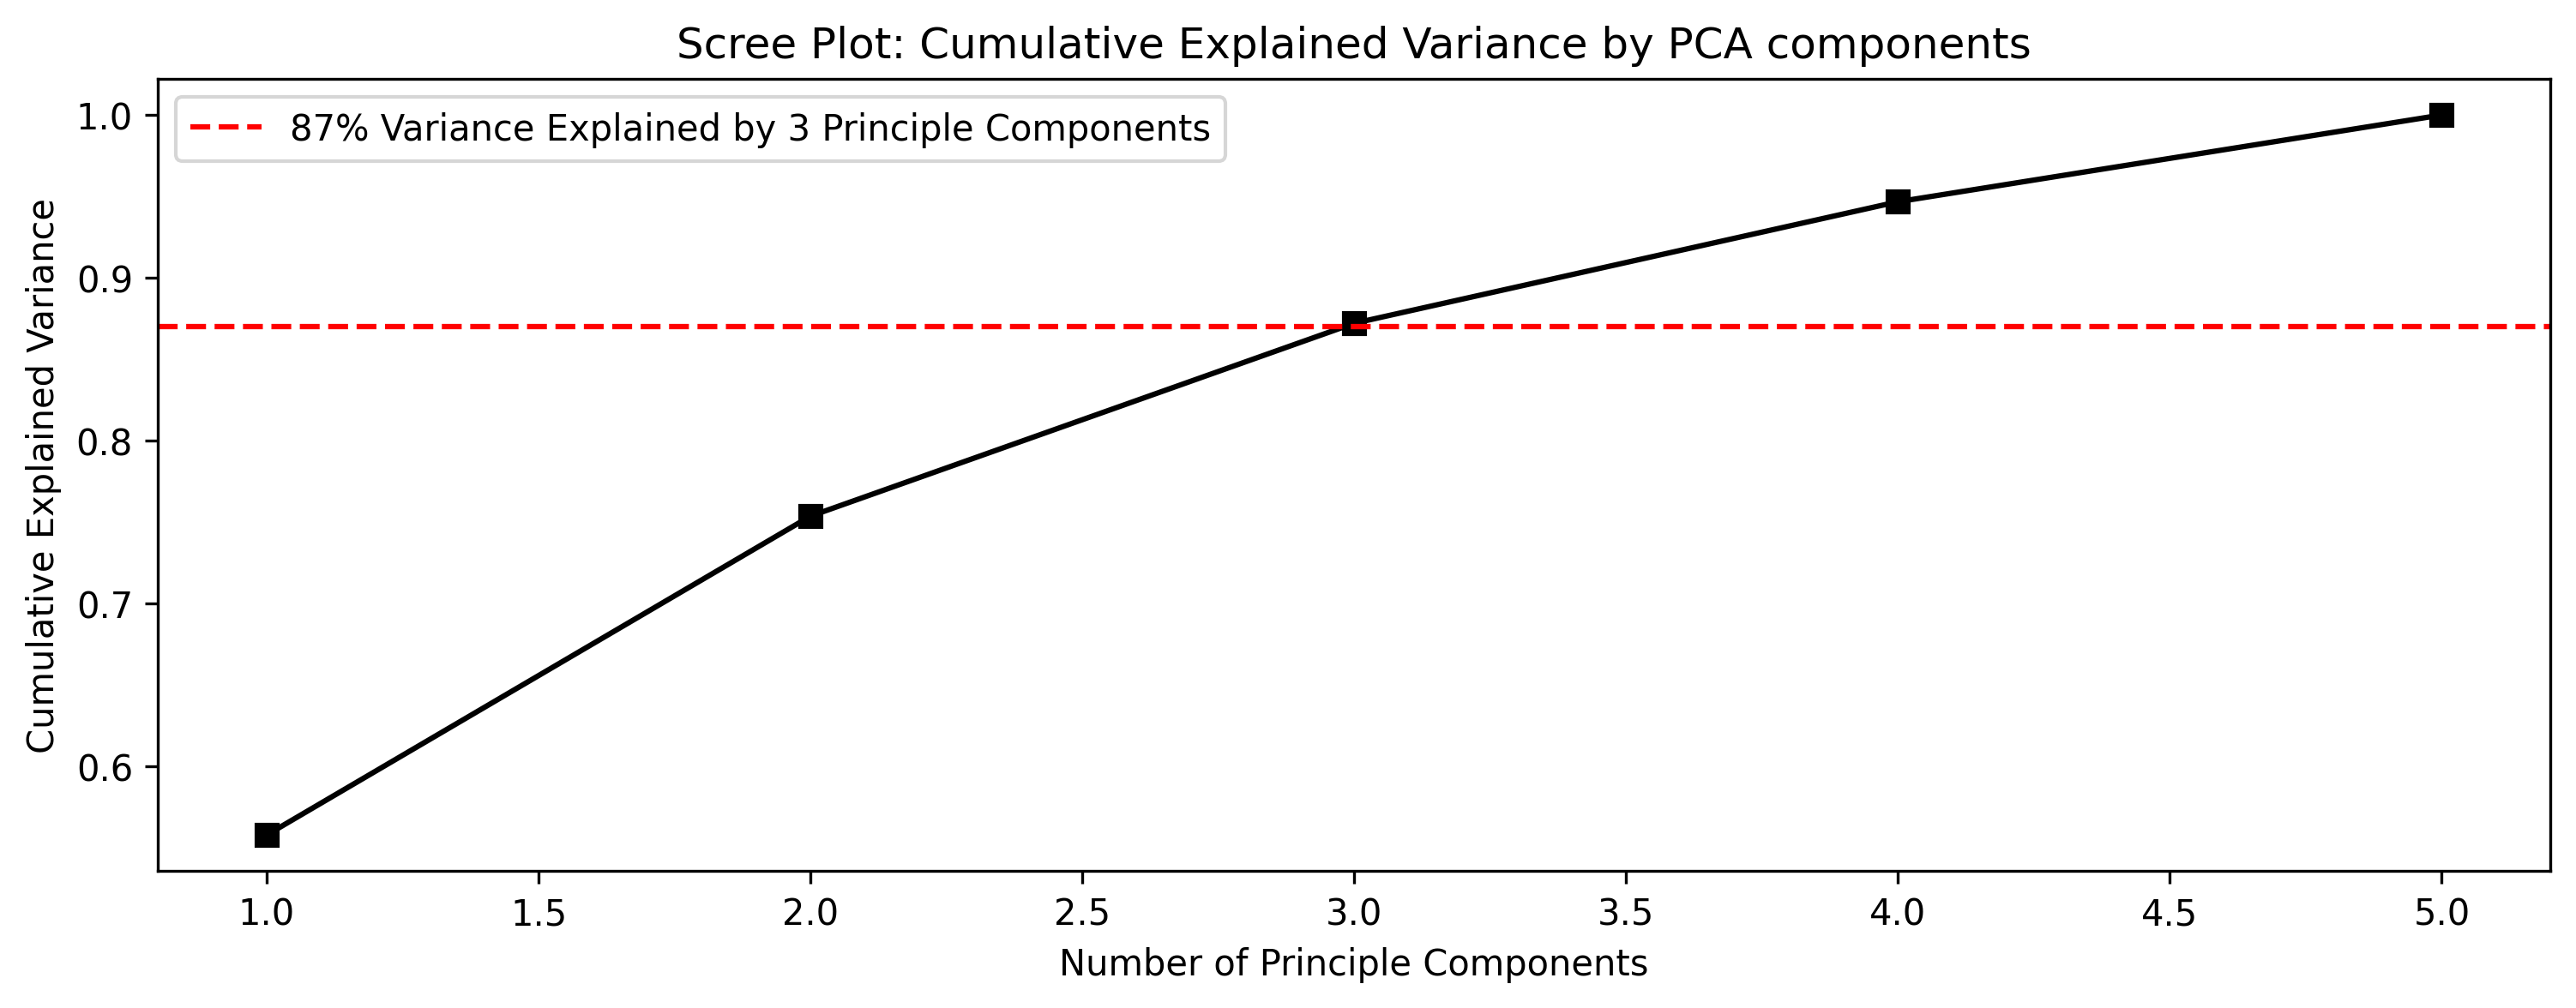

In [23]:
X = df.drop("CustomerID", axis = 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
x_axis = range(1, len(cumulative_variance) +1)

plt.figure(figsize = (12,4), dpi = 300)
plt.bar(x_axis, explained_variance, color = "skyblue")
plt.title("Scree Plot: Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(x_axis, cumulative_variance, marker = 's', color = 'black')
plt.axhline(y = 0.87, linestyle = '--', color = 'red', label = "87% Variance Explained by 3 Principle Components")
plt.title("Scree Plot: Cumulative Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

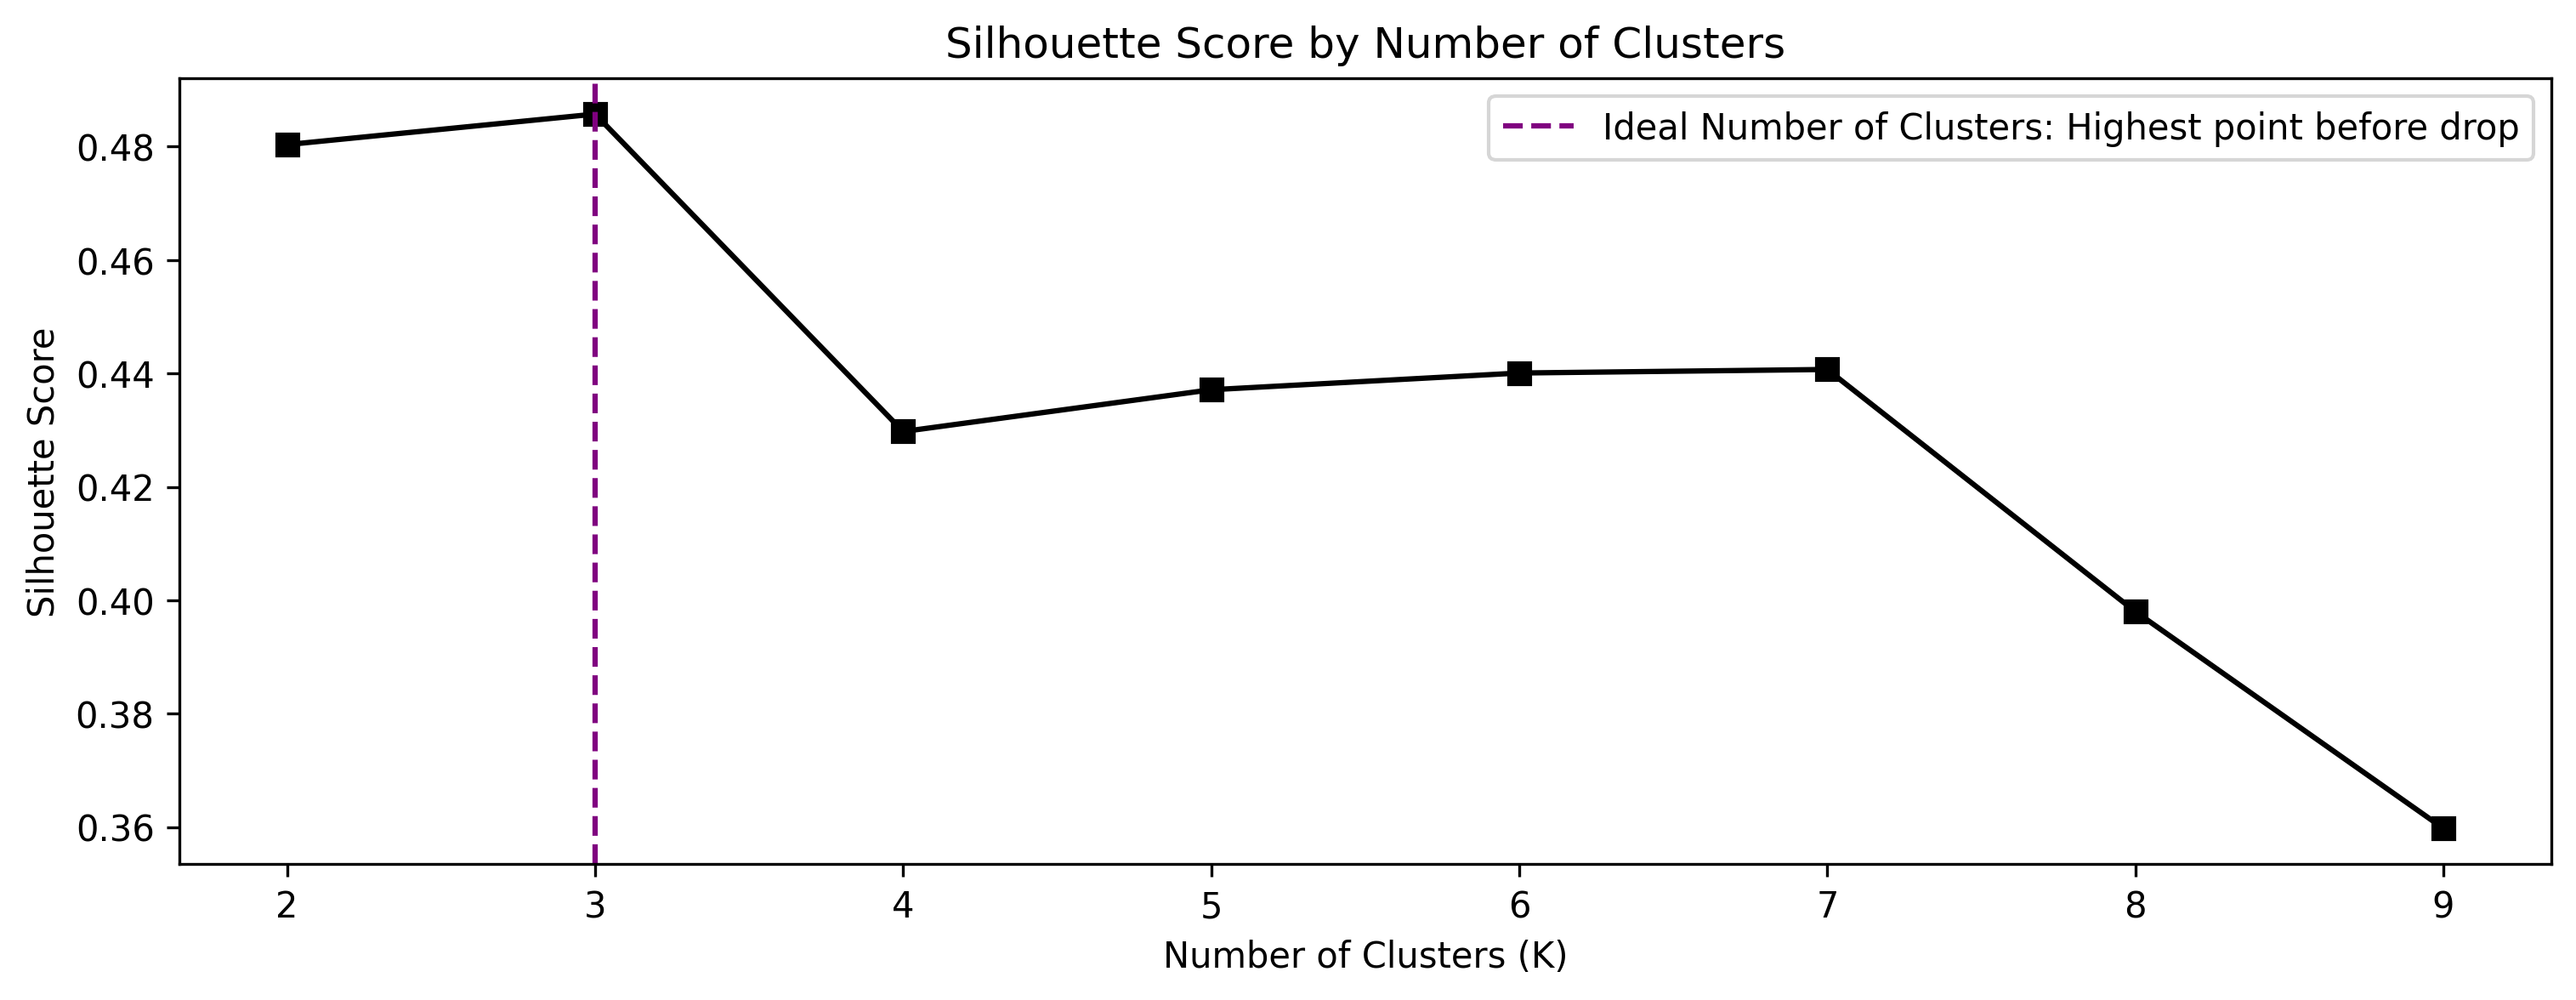

In [17]:
pca_components = 3

pca = PCA(n_components = pca_components)

X_pca = pca.fit_transform(X_scaled)

k_range = range(2,10)

s_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    k_labels = kmeans.fit_predict(X_pca)
    sil_score = silhouette_score(X_pca, k_labels)
    s_scores.append(sil_score)

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(k_range, s_scores, marker = 's', color = "black")
plt.axvline(x = 3, color = 'purple', linestyle = '--', label = "Ideal Number of Clusters: Highest point before drop")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()

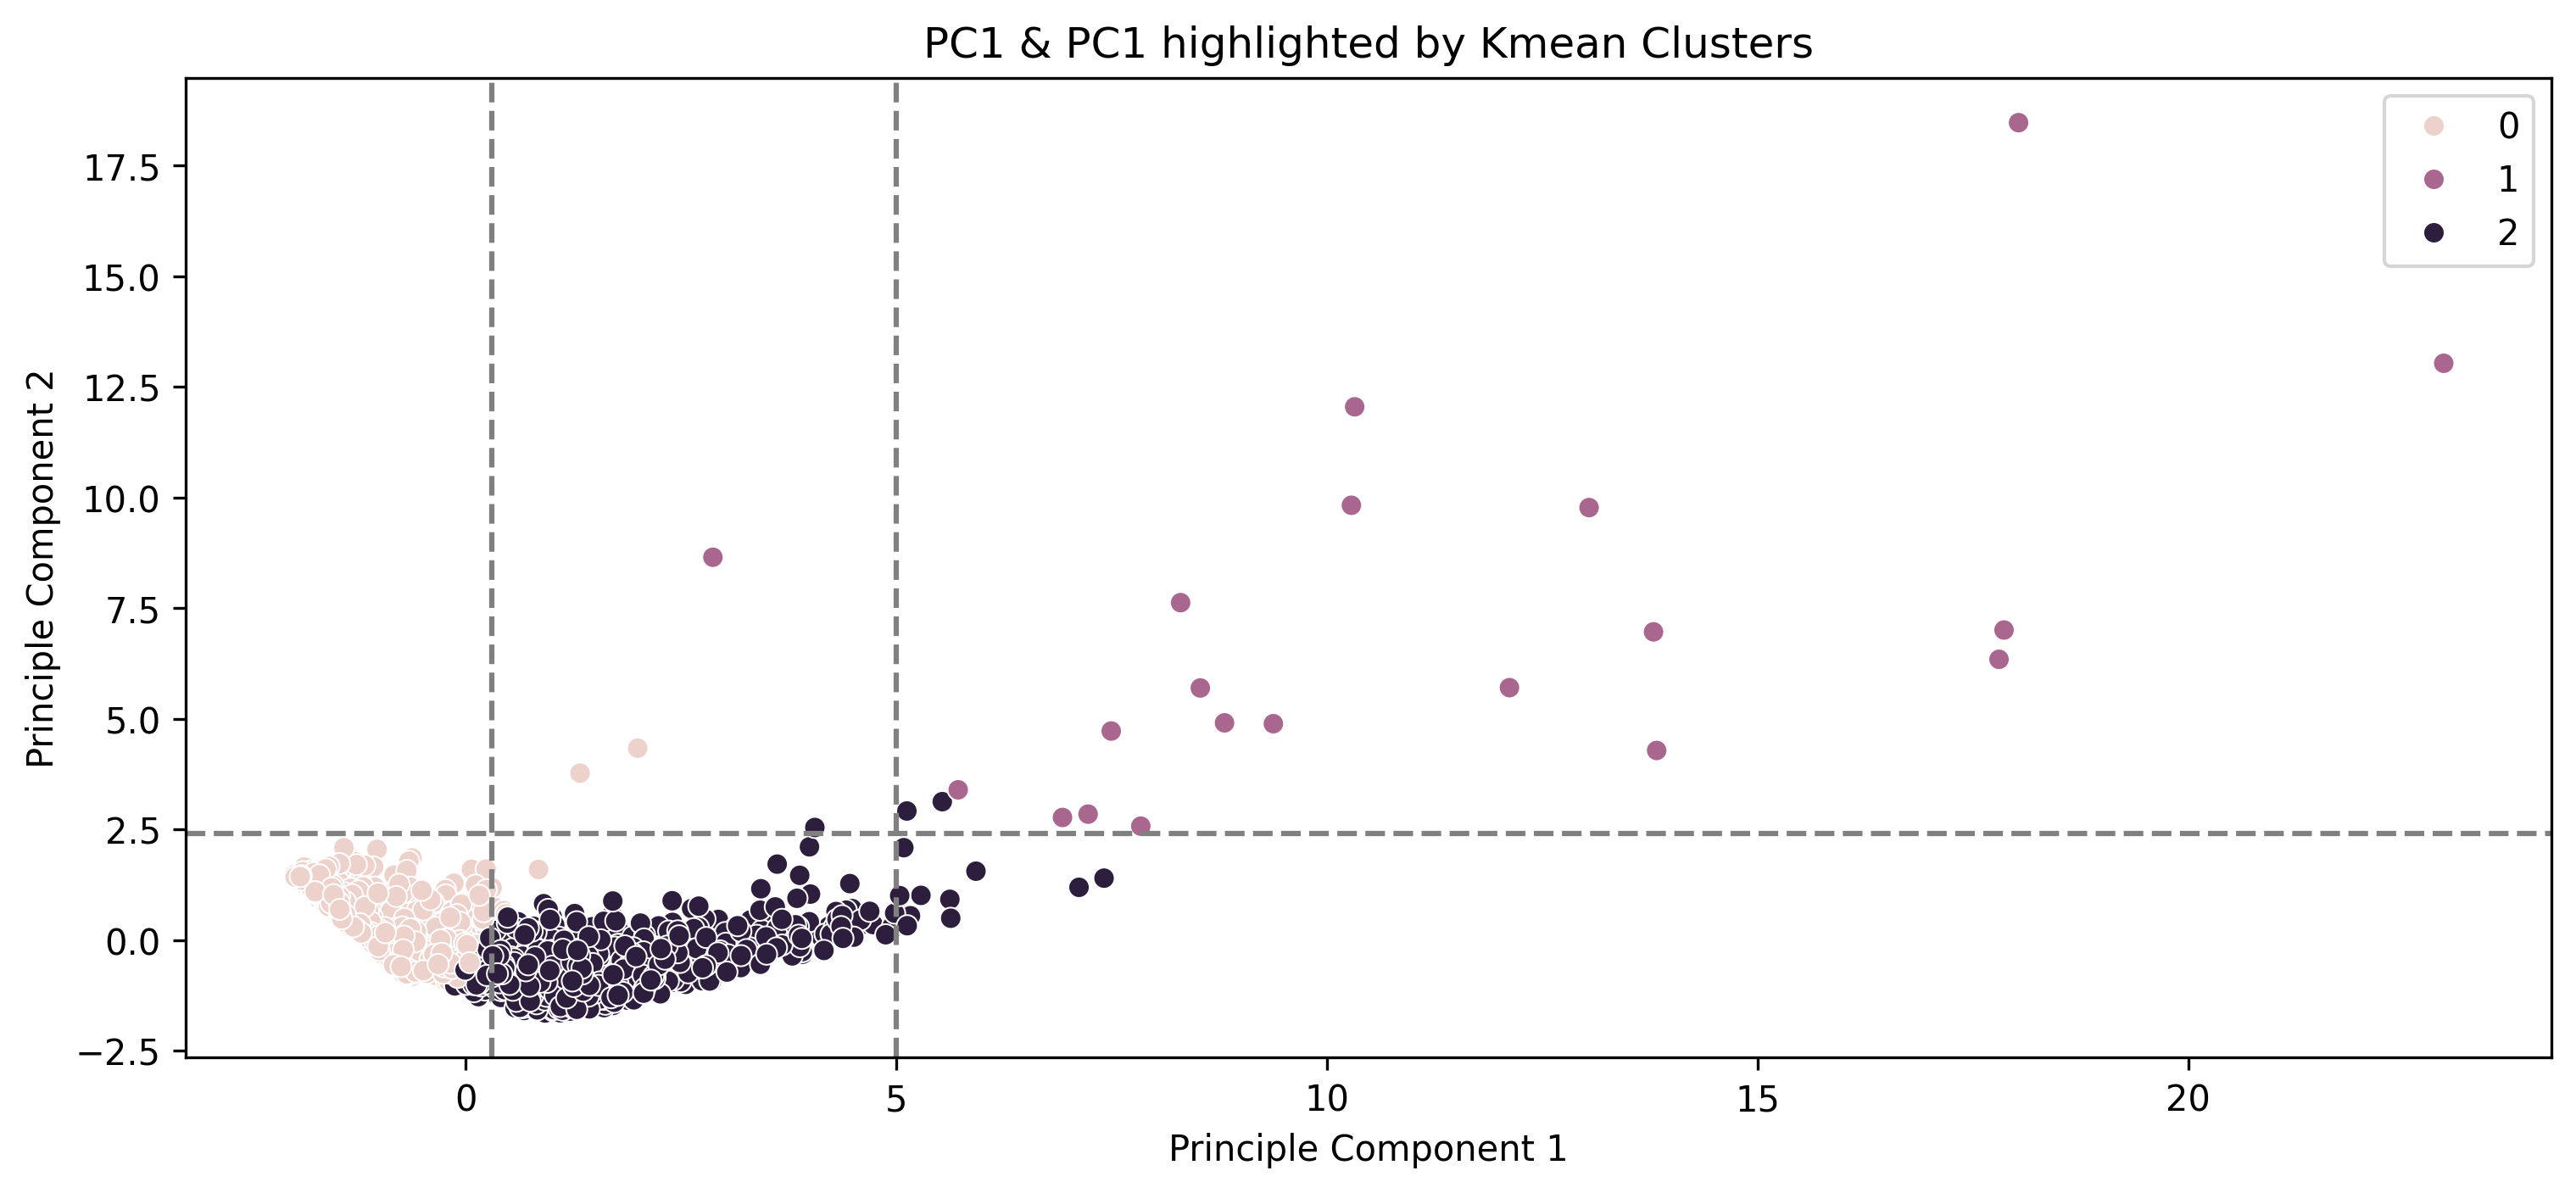

In [24]:
ideal_clusters = 3

kmeans = KMeans(n_clusters = ideal_clusters, random_state = 42, n_init = 10)
k_labels = kmeans.fit_predict(X_pca)


pc1 = X_pca[:,0]
pc2 = X_pca[:,1]

plt.figure(figsize = (12,5), dpi = 300)
sns.scatterplot(x = pc1, y = pc2, hue = k_labels)
plt.title("PC1 & PC1 highlighted by Kmean Clusters")
plt.axhline(y = 2.4, color = "grey", linestyle = '--')
plt.axvline(x = 0.3, color = "grey", linestyle = '--')
plt.axvline(x = 5, color = "grey", linestyle = '--')
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.show()

In [11]:
# Adding clusters view to Database
klabels_df = pd.DataFrame(df["CustomerID"])

klabels_df['KSegment'] = k_labels

with engine.begin() as conn:
    conn.execute(text('DROP TABLE IF EXISTS customer_segment_labels CASCADE'))
klabels_df.to_sql(
    name = "customer_segment_labels",
    con = engine,
    if_exists = "replace",
    index = False
)
print("Successfully created/updated customer_segment_lables table")

query = """
CREATE OR REPLACE VIEW v_segmented_data AS
SELECT "CustomerID",
    "Recency",
    "Frequency",
    "TotalRevenue",
    "Tenure",
    "ProductDiversity",
    "KSegment"
FROM v_customer_metrics
LEFT JOIN customer_segment_labels
USING("CustomerID")
"""

with engine.begin() as conn:
    conn.execute(text(query))
    print("Successfully created/updated v_segmented_data view")

print("\nData Preview of v_segmented_data view:")

df_segmented = pd.read_sql(text('SELECT * FROM v_segmented_data'), con = engine)
df_segmented.head()

Successfully created/updated customer_segment_lables table
Successfully created/updated v_segmented_data view

Data Preview of v_segmented_data view:


,CustomerID,Recency,Frequency,TotalRevenue,Tenure,ProductDiversity,KSegment
0,12346.0,325,1,77183.60,0,1,1
1,12347.0,129,5,2790.86,238,82,2
2,12348.0,248,3,1487.24,110,22,0
3,12350.0,310,1,334.40,0,17,0
4,12352.0,262,4,1561.81,34,26,0
